In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, precision_recall_fscore_support

sys.path.append(os.getcwd())

from feature_pipeline import prepare_datasets
from transformer_model import (
    TrainingConfig,
    build_user_sequences,
    make_dataloaders,
    ChurnTransformer,
    train_model,
    predict_proba,
    UserSequenceDataset,
    collate_batch,
)


In [2]:
BASE_PATH = os.getcwd()
train_path = f'{BASE_PATH}/churn-prediction-25-26/train.parquet'
test_path = f'{BASE_PATH}/churn-prediction-25-26/test.parquet'

config = TrainingConfig(
    d_model=128,
    nhead=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.35,          # ↑ 正则稍微拉高

    max_seq_len=500,      # ↓ 只保留每个用户最近 500 条左右
    batch_size=256,

    lr=5e-4,              # ↓ 学习率略调小一点
    weight_decay=1e-3,    # ↑ L2 正则稍微加强
    epochs=35,            # ↓ 不需要跑到 50

    use_cosine_decay=True,
    eta_min_factor=0.3,   # 底 LR 稍微抬高，避免后期太“死”
    warmup_epochs=3,
    use_focal_loss=False,
    focal_gamma=2.0,
    
    early_stop_patience=4,    # ↓ 更快地停在 val 最好附近
    early_stop_min_delta=1e-4,
)

# loss 建议：
# criterion = BCEWithLogitsLoss(pos_weight=torch.tensor([3.0]))
# 80/20 的数据，pos_weight 可以先取 3，之后视结果在 2~4 之间微调



train_df, val_df, test_df, labels, artifacts = prepare_datasets(
    train_path,
    test_path,
    val_ratio=0.2,
    random_state=42,
    truncate_buffer_min=2,
    truncate_buffer_frac=0.02,
    cutoff_time='2018-11-10',
    # drop_inactive_before_cutoff=False,
)
label_dict = labels.to_dict()
print('train rows', len(train_df), 'val rows', len(val_df), 'test rows', len(test_df))


100%|██████████| 4393179/4393179 [00:23<00:00, 185344.62it/s]


train rows 11373282 val rows 2814971 test rows 4393179


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_sequences = build_user_sequences(train_df, artifacts.numeric_cols, config.max_seq_len)
val_sequences = build_user_sequences(val_df, artifacts.numeric_cols, config.max_seq_len)
train_loader, val_loader = make_dataloaders(train_sequences, val_sequences, label_dict, config)

# The dataset is imbalanced; use pos_weight plus focal loss
# pos_weight = float((labels == 0).sum() / (labels == 1).sum())

pos_weight = 2

model = ChurnTransformer(
    num_numeric=len(artifacts.numeric_cols),
    num_pages=len(artifacts.page_categories),
    num_metro=len(artifacts.metro_mapping),
    num_state=len(artifacts.state_mapping),
    num_device=len(artifacts.device_mapping),
    config=config,
).to(device)
print(model)


ChurnTransformer(
  (page_emb): Embedding(21, 32, padding_idx=0)
  (metro_emb): Embedding(817, 16, padding_idx=0)
  (state_emb): Embedding(101, 12, padding_idx=0)
  (device_emb): Embedding(7, 6, padding_idx=0)
  (input_proj): Linear(in_features=81, out_features=128, bias=True)
  (input_dropout): Dropout(p=0.35, inplace=False)
  (pos_encoder): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.35, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.35, inplace=Fa

In [4]:
train_losses, val_losses, model, best_epoch, best_state = train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=config.epochs,
    lr=config.lr,
    weight_decay=config.weight_decay,
    pos_weight=pos_weight,
    use_cosine_decay=config.use_cosine_decay,
    eta_min_factor=config.eta_min_factor,
    warmup_epochs=config.warmup_epochs,
    use_focal_loss=config.use_focal_loss,
    focal_gamma=config.focal_gamma,
    early_stop_patience=config.early_stop_patience,
    early_stop_min_delta=config.early_stop_min_delta,
)
print('done training, best epoch:', best_epoch)


  0%|          | 0/35 [00:00<?, ?it/s]/Data/yuhan.wu/miniconda3/envs/py310/lib/python3.10/site-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(
 46%|████▌     | 16/35 [09:02<10:43, 33.88s/it]

done training, best epoch: 12


In [5]:
# Save the best validation model and artifacts
ckpt = {
    'model_state': best_state,
    'config': config.__dict__,
    'artifacts': artifacts,
    'numeric_cols': artifacts.numeric_cols,
    'best_epoch': best_epoch,
}
torch.save(ckpt, 'transformer_best.pt')
print('saved to transformer_best.pt (best epoch)', best_epoch)


saved to transformer_best.pt (best epoch) 12


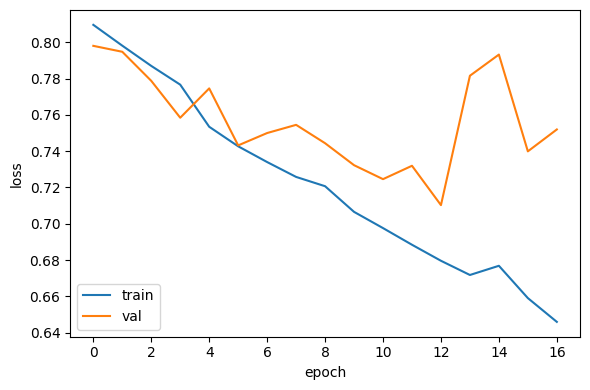

In [6]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150)
plt.show()


In [7]:
# Evaluate on validation set
val_probs = predict_proba(model, val_loader, device)
val_index = list(val_sequences.keys())
val_true = labels.loc[val_index]
val_pred = pd.Series(val_probs).reindex(val_index)

thresholds = np.round(np.arange(0.10, 0.901, 0.02), 2)
threshold_metrics = []
for thr in thresholds:
    preds = (val_pred >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        val_true, preds, average='binary', zero_division=0
    )
    acc = accuracy_score(val_true, preds)
    threshold_metrics.append(
        {
            'threshold': float(thr),
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': acc,
        }
    )

threshold_df = pd.DataFrame(threshold_metrics).sort_values('threshold')
best_row = max(threshold_metrics, key=lambda x: x['f1'])
best_threshold = best_row['threshold']
best_f1 = best_row['f1']
val_pred_binary = (val_pred >= best_threshold).astype(int)
auc = roc_auc_score(val_true, val_pred)
print(f"Best F1={best_f1:.4f} at threshold={best_threshold:.2f}")
print(
    "Validation accuracy@best: {acc:.4f}, precision={prec:.4f}, recall={rec:.4f}".format(
        acc=best_row['accuracy'], prec=best_row['precision'], rec=best_row['recall']
    )
)
print(f"Validation ROC-AUC: {auc:.4f}")
threshold_df.sort_values('f1', ascending=False).head()


Best F1=0.4756 at threshold=0.42
Validation accuracy@best: 0.7076, precision=0.3998, recall=0.5867
Validation ROC-AUC: 0.7298


,threshold,precision,recall,f1,accuracy
16,0.42,0.399840,0.586651,0.475558,0.707595
15,0.40,0.383212,0.614754,0.472122,0.689336
17,0.44,0.411504,0.544496,0.468750,0.721090
18,0.46,0.432567,0.507026,0.466846,0.738291
14,0.38,0.362968,0.635831,0.462128,0.665520


In [8]:
test_sequences = build_user_sequences(test_df, artifacts.numeric_cols, config.max_seq_len)
test_dataset = UserSequenceDataset(test_sequences, labels=None, user_ids=list(test_sequences.keys()))
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=config.num_workers,
    collate_fn=collate_batch,
)
test_probs = predict_proba(model, test_loader, device)
test_pred = pd.Series(test_probs)
submission = pd.DataFrame({
    'id': list(test_pred.index),
    'target': (test_pred >= best_threshold).astype(int).values
})
submission['id'] = pd.to_numeric(submission['id'], errors='ignore')
submission.to_csv('submission.csv', index=False)
submission.head()


/tmp/ipykernel_1560750/1449444081.py:16: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  submission['id'] = pd.to_numeric(submission['id'], errors='ignore')


,id,target
0,1000655,0
1,1000963,1
2,1001129,0
3,1001963,1
4,1002283,0
